# Applications

*Four missions on the motion verbs: a throttle lane, a cruise through a gust, two joints on one wire, and a hold against a load step.*

**Abstract.** The drive commutates itself at 50 kHz from the record's tune; what a flight controller or a motion planner does with this board at the far end of a wire runs at link rate, tens of hertz, through `coaxial.control.motion`. This notebook runs four such missions on the stand-in's rotor, and on a board with the knob flipped: one lane of a quadrotor stepped through four speeds under a propeller law, a fixed-wing cruise holding 2500 rpm through a gust that multiplies the drag by 2.5 for one second, a two-joint arm with one board per joint - `shoulder` and `elbow`, unit 1 and unit 2 on one segment - and a servo holding 30 degrees at 3 A while 0.03 N.m steps onto the shaft. The propeller is `Propeller.on_model`, the law fed to the model's load every pass; the loop's own `load_k` is only what its feedforward knows about it. What it measures: the pass rate the lane managed against the 25 a second asked for, the speed each target settled at and its spread, the current the gust cost and what the loop gave back, the worst position error of either joint against a 0.5 degree tolerance, and the sag, the residual and the ring of a held shaft through the load step. Headline: 25 passes a second at 40 ms each, every speed within 3 % of asked, the cruise held within 40 rpm of 2500 through the gust for 0.1 A more current, both joints within 0.1 degree on every pose, and the hold sagging 1.6 degrees under the load and corrected to within 0.05 of the command. What a reader takes to the bench: a speed reference slews and a position is corrected between moves, never closed per pass; stiffness is current, not gain; and a second joint is a second unit id on the same wire.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The stage, armed

Every mission runs the drive on the stand-in's rotor, `source('model')`, with the machine's inertia and friction set to the smallest plausible pair, and the stage armed once here: `gates.arm()` is the one place arming lives, and the verbs refuse an unarmed stage. The two flags are for a bench with no STO chain unlocked and an unmodified interlock; at the bench the pilot tone releases the drivers' supply and the flags go.

In [3]:
drive = device.drive
drive.source('model')
print(drive.model_param(j=2e-5, b=1e-5, load=0.0))
device.gates.arm(bypass_sto=True, ignore_interlock=True)
print('armed:', device.gates.armed())

{'j': 2e-05, 'b': 1e-05, 'load': 0.0}
armed: True


## 3 The propeller on the rotor

`Propeller(k)` is the law `T = k w^2`, and `on_model(drive, log)` is a `watch` for `Velocity.rpm`: each pass it reads the model's speed and feeds the torque the law gives to the model's load, logging `(seconds, rpm asked, rpm now, iq asked)`. `APC20x10E` is the propeller the 5230SL was tested with, fitted over the 22 rows of Hobbywing's own thrust stand; on the stand-in's small machine it wants more current at 3500 rpm than the lane is opened with, so the missions turn an ad-hoc k. A pass is one state read and one setpoint write with a 40 ms pause between; at the bench each of the two adds its own round trip on the link, about 7 ms for the write.

In [4]:
from coaxial.model.motor import APC20x10E, Propeller
from coaxial.model.sensorless import RAD_S_PER_RPM

K_PROP = 2e-8
prop = Propeller(K_PROP, name='stand-in propeller')
tune = drive.params()
poles = int(tune['motor_pole_pairs'])
kt = 1.5 * poles * tune['motor_lambda_uvs']
top = 3500.0 * RAD_S_PER_RPM
print(prop, ' ', APC20x10E)
print('kt %.4f N.m/A from the record, %d pole pairs' % (kt, poles))
for law in (prop, APC20x10E):
    torque = law.torque(top * poles, poles)
    print('%-20s at 3500 rpm: %.4f N.m, %5.2f A of iq' % (law.name, torque, torque / kt))

<stand-in propeller: 2.000e-08 N.m/(rad/s)^2>   <APC20x10E: 5.143e-06 N.m/(rad/s)^2>
kt 0.0525 N.m/A from the record, 7 pole pairs
stand-in propeller   at 3500 rpm: 0.0027 N.m,  0.05 A of iq
APC20x10E            at 3500 rpm: 0.6909 N.m, 13.16 A of iq


## 4 A throttle lane

One motor of a quadrotor: `velocity` opened with a 2 A clamp, a 3 Hz loop and the propeller law as `load_k`, stepped through four speeds and held two seconds at each, the air fed to the rotor by `on_model`. The verb reads `omega_hat` and writes `iq_ref` at link rate, and nothing here runs faster than tens of hertz: a quad's rate loop belongs where 50 kHz lives, in `drive/`. The reference slews rather than steps, reaching the target in a third of the block by default, so the current stays a control action instead of a step into the clamp. Wall time is taken around the four holds, so the pass rate is what the link managed and not the pause asked for.

In [5]:
import time

LANE = ((1500.0, 2.0), (3000.0, 2.0), (2000.0, 1.5), (3500.0, 2.0))
lane_log, lane_settled = [], []
with device.motion.velocity(amps=2.0, hz=3.0, load_k=K_PROP) as lane:
    air = prop.on_model(drive, lane_log)
    began = time.monotonic()
    for rpm, hold in LANE:
        got = lane.rpm(rpm, seconds=hold, watch=air)
        lane_settled.append((rpm, got))
        print('asked %5.0f  settled %5.0f rpm  (%+5.1f %%)' % (rpm, got, 100.0 * (got - rpm) / rpm))
    lane_wall = time.monotonic() - began
    lane.stop(seconds=1.0)
    lane_pause = lane.pause
drive.model_param(load=0.0)
print('%d passes in %.1f s: %.1f a second, %.0f ms a pass against %.0f ms asked'
      % (len(lane_log), lane_wall, len(lane_log) / lane_wall,
         1000.0 * lane_wall / len(lane_log), 1000.0 * lane_pause))

asked  1500  settled  1493 rpm  ( -0.4 %)


asked  3000  settled  2932 rpm  ( -2.3 %)


asked  2000  settled  2058 rpm  ( +2.9 %)


asked  3500  settled  3324 rpm  ( -5.0 %)


188 passes in 7.6 s: 24.7 a second, 41 ms a pass against 40 ms asked


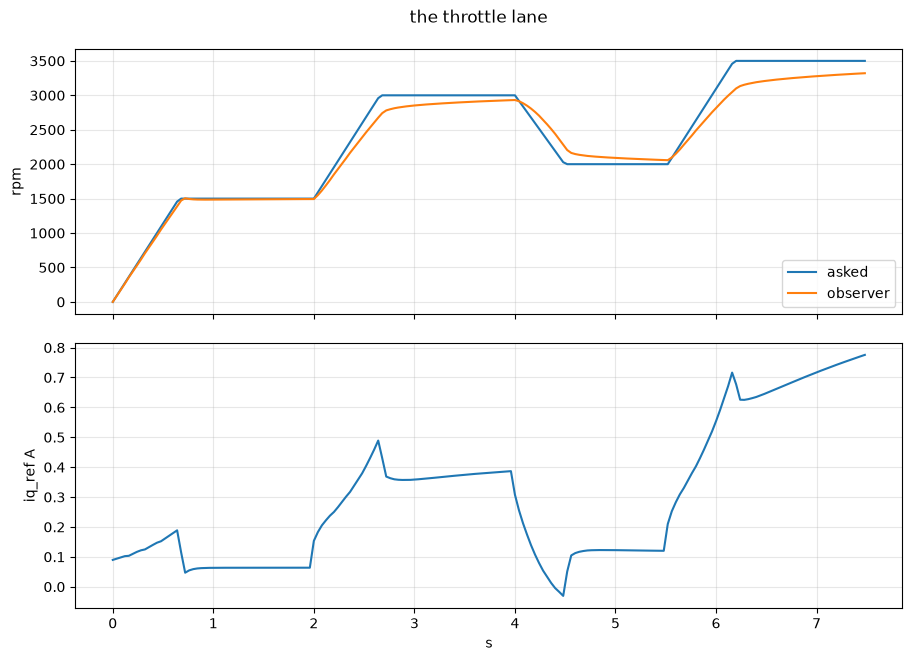

In [6]:
from coaxial.draw.figures import figure, show

def draw(log, title):
    t = [r[0] for r in log]
    fig, (speed, current) = figure(rows=2, sharex=True, title=title)
    speed.plot(t, [r[1] for r in log], label='asked')
    speed.plot(t, [r[2] for r in log], label='observer')
    speed.set_ylabel('rpm')
    speed.legend(loc='lower right')
    current.plot(t, [r[3] for r in log])
    current.set_ylabel('iq_ref A')
    current.set_xlabel('s')
    show(fig)

draw(lane_log, 'the throttle lane')

## 5 A cruise through a gust

A fixed wing at one speed: 2500 rpm asked, reached in 1.5 s, then held 5 s while the reference stands still. Between 3.5 and 4.5 s of the block the drag on the rotor is multiplied by 2.5 - the gust - and the loop's `load_k` is not told. The speed error is what the loop sees and the current is what it answers with: the feedforward already carries the still-air drag `k w |w|`, so the integrator only has to find what the gust adds, and gives it back when it passes. The clamp is `limit`, the 2 A the verb was opened with. Three windows are read back: cruise before the gust, the gust, and a second after it.

cruise      2464 rpm, spread  53, iq_ref 0.21 A over 50 passes
gust        2403 rpm, spread 105, iq_ref 0.27 A over 25 passes
recovered   2527 rpm, spread  19, iq_ref 0.22 A over 24 passes
after the gust: 2518 rpm


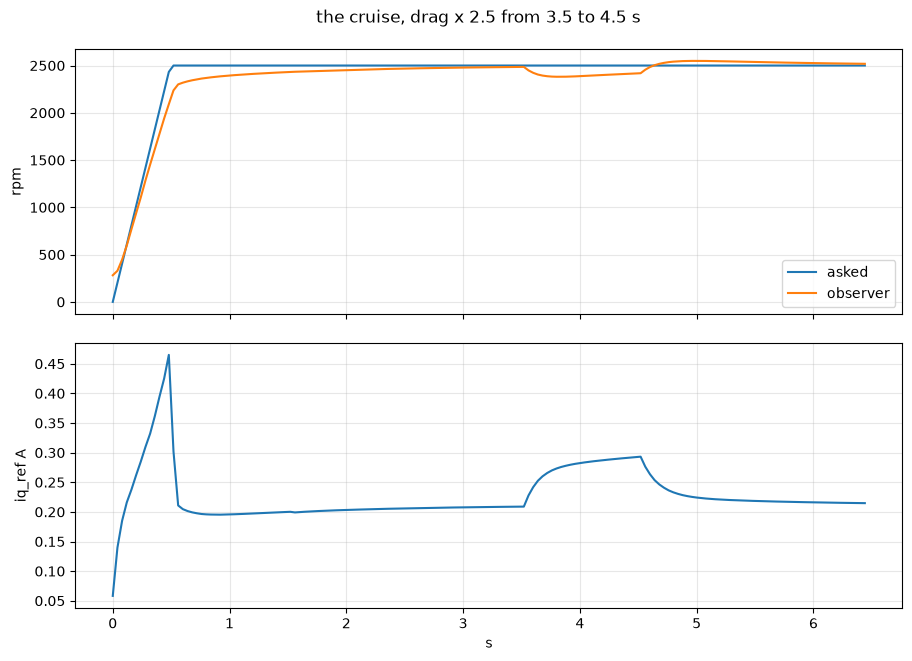

In [7]:
K_CRUISE = 2e-8
GUST, GUST_FROM, GUST_TO = 2.5, 3.5, 4.5        # times the drag, over which seconds
cruise_log = []
still_air = Propeller(K_CRUISE).on_model(drive, cruise_log)

def gusty(verb):
    still_air(verb)                             # the row, and the still-air load
    if GUST_FROM <= cruise_log[-1][0] < GUST_TO:
        wm = drive.model()['omega'] / verb.poles
        drive.model_param(load=GUST * K_CRUISE * wm * abs(wm))

with device.motion.velocity(amps=2.0, hz=2.0, load_k=K_CRUISE) as cruise:
    cruise.rpm(2500.0, seconds=1.5, watch=gusty)
    cruise.rpm(2500.0, seconds=5.0, watch=gusty)
    after_gust = cruise.rpm_now
    cruise.stop(seconds=1.0)
drive.model_param(load=0.0)

def window(log, lo, hi):
    rows = [r for r in log if lo <= r[0] < hi]
    speed = [r[2] for r in rows]
    return (sum(speed) / len(speed), max(speed) - min(speed),
            sum(r[3] for r in rows) / len(rows), len(rows))

WINDOWS = (('cruise', 1.5, GUST_FROM), ('gust', GUST_FROM, GUST_TO), ('recovered', 5.5, 6.5))
cruise_windows = {name: window(cruise_log, lo, hi) for name, lo, hi in WINDOWS}
for name, (mean, spread, amps, passes) in cruise_windows.items():
    print('%-10s %5.0f rpm, spread %3.0f, iq_ref %.2f A over %d passes' % (name, mean, spread, amps, passes))
print('after the gust: %.0f rpm' % after_gust)
draw(cruise_log, 'the cruise, drag x %.1f from %.1f to %.1f s' % (GUST, GUST_FROM, GUST_TO))

## 6 Two joints on one wire

One board per joint on one serial segment: the board Setup opened is unit 1 and drives the shoulder, and this section opens unit 2, the elbow, the same way - `shoulder` and `elbow` are those two handles from here on. A Modbus RTU frame carries the unit id first and every node on the wire sees every frame; on the stand-in each unit is its own board. The elbow carries a standing 0.01 N.m, which is what a link hanging off it is.

In [8]:
shoulder = device
elbow = Coaxial63100(port=PORT, unit=2, simulated_device=SIMULATED).open()
elbow.drive.source('model')
elbow.drive.model_param(j=2e-5, b=1e-5, load=0.01)
elbow.gates.arm(bypass_sto=True, ignore_interlock=True)
for name, joint in (('shoulder', shoulder), ('elbow', elbow)):
    print('%-9s unit %d  %s  armed %s' % (name, joint.origin.unit, joint, joint.gates.armed()))

shoulder  unit 1  <Coaxial63100 Simulated SIMULATED>  armed True
elbow     unit 2  <Coaxial63100 Simulated SIMULATED>  armed True


A move is a pair of targets. Each servo slews its command at 90 degrees a second, lets the ring die, reads its shaft as a mean over the ring, and corrects what the load stole - up to four corrections a move, inside 0.5 degree. The elbow is put back and closed here; the shoulder is the device and stays armed for the hold.

In [9]:
POSES = ((30.0, 60.0), (60.0, 20.0), (0.0, 0.0))
reached = []
with shoulder.motion.servo(amps=2.0) as s, elbow.motion.servo(amps=2.0) as e:
    for a, b in POSES:
        got_a = s.to(a, tol=0.5)
        got_b = e.to(b, tol=0.5)
        reached.append((a, b, got_a, s.error, s.swing, got_b, e.error, e.swing))
        print('pose (%5.1f, %5.1f)  shoulder %6.2f err %5.2f swing %4.2f   elbow %6.2f err %5.2f swing %4.2f'
              % reached[-1])
elbow.gates.disarm()
elbow.drive.model_param(load=0.0)
elbow.drive.source('adc')
elbow.close()
print(elbow)

pose ( 30.0,  60.0)  shoulder  30.03 err -0.03 swing 2.81   elbow  60.03 err -0.03 swing 4.75


pose ( 60.0,  20.0)  shoulder  59.99 err  0.01 swing 2.02   elbow  20.01 err -0.01 swing 2.11


pose (  0.0,   0.0)  shoulder  -0.00 err  0.00 swing 1.05   elbow   0.09 err -0.09 swing 0.97
<Coaxial63100 Simulated SIMULATED>


## 7 A hold against a load step

A servo holds 30 degrees at 3 A. HOLD commutates on the commanded angle, and the rotor sits where `amps kt sin(delta)` balances the load: a 0.03 N.m step on the model pulls the shaft off the command by that spring's sag, and the next correction takes it back. The shaft is read every 2 ms through each phase, and that pace is a physical choice: a held rotor rings at some 30 Hz, and a read every 20 ms drew the ring aliased into a slow sawtooth that looked filtered and subsampled (FINDINGS, 2026-09-07). On a link the A1335 answers every 15 ms or so; a trace this fine is the model's. The sensor's zero is the magnet's and the servo's frame starts at its detent, so the trace is read relative to the hold - every read folded about the sensor's reading at the held position - and the sag and the residual are differences on it. This is the last section on the stage, so it is disarmed at the end and the drive put back on the converters.

In [10]:
def watch_shaft(seconds, about, every=0.002):
    rows = []
    t0 = time.monotonic()
    while time.monotonic() - t0 < seconds:
        now = device.angle.state()['degrees']
        rows.append((time.monotonic() - t0, (now - about + 180.0) % 360.0 - 180.0))
        time.sleep(every)
    return rows

with device.motion.servo(amps=3.0, settle=0.3) as hold:
    zero = hold.to(30.0, tol=0.25)
    print('held at %.2f deg, error %.2f, swing %.2f' % (zero, hold.error, hold.swing))
    origin = device.angle.state()['degrees']
    before = watch_shaft(0.5, origin)
    drive.model_param(load=0.03)
    during = watch_shaft(0.8, origin)
    corrected = hold.to(30.0, tol=0.25)
    print('after the load step: shaft %.2f deg, error %.2f, swing %.2f'
          % (corrected, hold.error, hold.swing))
    after = watch_shaft(0.5, origin)
    drive.model_param(load=0.0)
print('the sensor read %.2f deg at the hold; the trace counts from there' % origin)
device.gates.disarm()
drive.source('adc')
print('armed:', device.gates.armed(), ' drive:', drive.state()['mode'])

held at 29.99 deg, error 0.01, swing 0.53


after the load step: shaft 30.01 deg, error -0.01, swing 1.67


the sensor read 59.85 deg at the hold; the trace counts from there
armed: False  drive: off


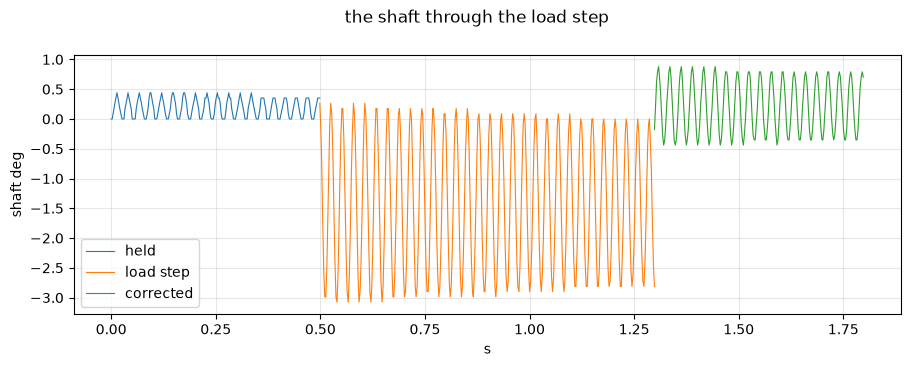

In [11]:
fig, (shaft,) = figure(rows=1, title='the shaft through the load step')
t = 0.0
for rows, label in ((before, 'held'), (during, 'load step'), (after, 'corrected')):
    shaft.plot([t + r[0] for r in rows], [r[1] for r in rows], linewidth=0.8, label=label)
    t += rows[-1][0]
shaft.set_xlabel('s')
shaft.set_ylabel('shaft deg')
shaft.legend(loc='lower left')
show(fig)

In [12]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 8 Conclusions

In [13]:
def held_at(log, target):
    rows = [r[2] for r in log if abs(r[1] - target) < 1.0]
    rows = rows[len(rows) // 2:]
    return sum(rows) / len(rows), max(rows) - min(rows), len(rows)

print('1. lane        %d passes in %.1f s: %.1f a second, %.0f ms a pass against %.0f ms asked'
      % (len(lane_log), lane_wall, len(lane_log) / lane_wall,
         1000.0 * lane_wall / len(lane_log), 1000.0 * lane_pause))
print('   iq_ref      %.2f A peak, %.2f A mean, clamp 2.0 A'
      % (max(abs(r[3]) for r in lane_log), sum(r[3] for r in lane_log) / len(lane_log)))
for asked, settled in lane_settled:
    mean, spread, passes = held_at(lane_log, asked)
    print('   at %4.0f rpm  settled %4.0f (%+5.1f %%), held %4.0f, spread %3.0f rpm over %d passes'
          % (asked, settled, 100.0 * (settled - asked) / asked, mean, spread, passes))
print('2. cruise      reference %.0f rpm from %.1f to %.1f s, gust x %.1f from %.1f to %.1f s'
      % (max(r[1] for r in cruise_log), 1.5, cruise_log[-1][0], GUST, GUST_FROM, GUST_TO))
for name, (mean, spread, amps, passes) in cruise_windows.items():
    print('   %-11s %5.0f rpm, spread %3.0f, iq_ref %.2f A over %d passes' % (name, mean, spread, amps, passes))
print('   after       %.0f rpm; the gust cost %.2f A more than cruise, %.2f A of it given back'
      % (after_gust, cruise_windows['gust'][2] - cruise_windows['cruise'][2],
         cruise_windows['gust'][2] - cruise_windows['recovered'][2]))
print('3. arm         worst shoulder error %.2f deg, worst elbow error %.2f deg under 0.01 N.m'
      % (max(abs(r[3]) for r in reached), max(abs(r[6]) for r in reached)))
print('   swing       up to %.2f deg shoulder, %.2f deg elbow while measured; tolerance 0.50 deg, up to 4 corrections a move'
      % (max(r[4] for r in reached), max(r[7] for r in reached)))
held = sum(r[1] for r in before) / len(before)
pulled = sum(r[1] for r in during[len(during) // 2:]) / (len(during) - len(during) // 2)
back = sum(r[1] for r in after) / len(after)
print('4. hold        %.2f deg held (asked 30.00); %.2f under 0.03 N.m, sag %.2f; %.2f corrected, residual %+.2f'
      % (held, pulled, pulled - held, back, back - 30.0))
print('   ring        %.2f deg peak to peak held, %.2f under the load, %.2f corrected; sampled at %.0f Hz; 3.0 A, tol 0.25 deg'
      % tuple([max(r[1] for r in rows) - min(r[1] for r in rows) for rows in (before, during, after)]
              + [len(before) / before[-1][0]]))

1. lane        188 passes in 7.6 s: 24.7 a second, 41 ms a pass against 40 ms asked
   iq_ref      0.78 A peak, 0.30 A mean, clamp 2.0 A
   at 1500 rpm  settled 1493 ( -0.4 %), held 1491, spread   4 rpm over 17 passes
   at 3000 rpm  settled 2932 ( -2.3 %), held 2913, spread  41 rpm over 17 passes
   at 2000 rpm  settled 2058 ( +2.9 %), held 2072, spread  30 rpm over 13 passes
   at 3500 rpm  settled 3324 ( -5.0 %), held 3293, spread  61 rpm over 17 passes
2. cruise      reference 2500 rpm from 1.5 to 6.4 s, gust x 2.5 from 3.5 to 4.5 s
   cruise       2464 rpm, spread  53, iq_ref 0.21 A over 50 passes
   gust         2403 rpm, spread 105, iq_ref 0.27 A over 25 passes
   recovered    2527 rpm, spread  19, iq_ref 0.22 A over 24 passes
   after       2518 rpm; the gust cost 0.07 A more than cruise, 0.06 A of it given back
3. arm         worst shoulder error 0.03 deg, worst elbow error 0.09 deg under 0.01 N.m
   swing       up to 2.81 deg shoulder, 4.75 deg elbow while measured; tolerance

**The lane.** The reference slews rather than steps - by default it reaches the target in a third of the block - so the current stays a control action instead of a step into the clamp. The loop's PI cancels the mechanical pole: kp is `w0 J / kt`, and the plant about the reference is `J s + b + 2 k |w_ref|`, because a propeller linearises to twice its slope. The feedforward carries the acceleration and the standing drag, and the integrator holds on the current clamp and on the inner loop's `v_sat` - past either, error is not information. `j` and `b` default to the smallest plausible machine on purpose: an overstated `j` scales kp by the same factor, and the discrete loop flips sign and doubles - measured, `j` five times the plant took +900 rpm asked to -1552 delivered. Understating only makes a big machine sluggish; `coaxial.model.sysid` and the motion notebook identify the real pair. The pass rate is the stand-in's: 25 a second is the 40 ms pause and nothing else, and at the bench each pass pays a state read and a setpoint write on the link.

**The gust.** The reference never moved: the speed error is what the loop sees, and the current is what it answers with. A load that grows with the square of speed cannot be carried by `b`, a linear drag - that reaches the same speed at a torque which is wrong everywhere except the one point it was fitted at, which is why `Motor` carries `k_load` separately and `Propeller` is its own class. The feedforward already knows the standing drag `k w |w|`, so the integrator only has to make up the difference the gust adds, and it gives it back when the gust passes. The clamp is `limit`, the amps the verb was opened with.

**The arm.** Two boards, two unit ids, one segment. A Modbus RTU frame carries the unit id first and every node on the wire sees every frame; `link.port_stats()` counts `bus_message` for what passed and `server_message` for what was addressed here, so `for_others` is the traffic meant for the other joint. Unit 0 is broadcast - every node acts, none answers, and reads are refused. Each joint holds its own current vector, so nothing about the pair is coupled through the drive: what couples them is the arm, and the elbow's standing load is what its own servo corrects out. The correction is what the load stole - a spring wound by holding torque, or poles slipped outright. This mission failed two runs in three between 2026-09-04 and 2026-09-07, and neither defect was in the notebook (FINDINGS, the motion verbs): nine shaft reads 22 ms apart aliased a 28 Hz ring to 17 Hz and left up to a degree of it in the mean, each correction re-kicked the spring, and the corrections pumped - +0.62, -1.03, +0.70, -0.57 - until `tries` ran out; and the stand-in's rotor was integrated at a sub-step re-sized every poll, so its ring decayed with a 16 s constant where 2j/b is 4 s. A shaft seen moving more than the slew's pitch is now read for a full second, some thirty periods of the ring, and the elbow lands within 0.09 degree on every pose - a run that takes 30 s where it took 15, the measurement's price.

**The hold.** The sag is the load-angle spring at work: HOLD commutates on the COMMANDED angle, and the rotor sits wherever `amps kt sin(delta)` balances the load. That angle is the error, and it is a fact about the torque - a stiffer hold is more current, not a tighter loop. The correction moves the command by the measured error, so the spring is re-centred rather than fought. Nothing here runs a position loop per pass: the ring is at the same frequency the link corrects at, and closing per pass samples its own resonance aliased and pumps it - six clean passes once wound the rotor through a pole slip into a freewheel. The servo measures the ring's MEAN - a shaft seen moving is read for a whole second - and `swing` is how far it moved while the measurement watched. Arriving is two readings a settle apart, not one: a shaft the load drags past the target reads exactly like one holding on it, and `to()` once returned 29.84 degrees against 30.0 under 1.2 N.m with 0.18 N.m of holding torque, caught by CI 2026-09-04. A shaft that stays outside `tol` after `tries` corrections raises with what it saw - the load is past the holding torque, or there is no magnet in front of the sensor. FINDINGS recorded this trace 2026-09-07: 0.18 degree peak to peak held, 3.34 the moment 0.03 N.m steps on, a sag of 1.58, 0.62 after the correction, at 427 Hz through each phase. Every number in this notebook is the model's (invariant 10): nothing in it has been near a motor.

**At the bench.** Flip `SIMULATED`, name the port, and take the two flags off `gates.arm()`: at the bench the STO chain releases the drivers' supply on the pilot tone and the interlock is the schematic's. Drop `on_model` and the gust - the air is the air - and open the lane with `load_k` set to the propeller it really turns, `APC20x10E.k` for the 5230SL; write the record's tune first, in the commissioning notebook, or the observer has nothing to lock to. Compare conclusion 1's pass rate against 25 a second: a pass on the link is a state read and a setpoint write, and the number is what the wire managed. Compare the settled speeds against a tachometer, not against the observer that closed the loop. For the arm, two units on one RS485 segment: `elbow.link.port_stats(port)['for_others']` climbs with the shoulder's traffic, which is the address filter working; the stand-in has no shared segment and shows 0. For the hold, hang a known weight and read `swing`: the A1335 answers every 15 ms or so, so the 2 ms trace does not exist on a link, and the sag and the residual are what to compare. The stand-in could not show a trip mid-move, a pole slipped under a real load, or a gust with dynamics of its own; a trip ends the block with the board's own word.

## References

* `host/coaxial/control/motion.py` - the three verbs: the slew, the servo's mean over the ring, the velocity loop at link rate
* `host/coaxial/control/loop.py` - `SpeedLoop`: kp from the mechanical pole, the feedforward, the integrator held on the clamp and `v_sat`
* `host/coaxial/model/motor.py` - `Propeller`, `on_model`, `APC20x10E` off the thrust stand, and `Motor` with `k_load` beside `b`
* `host/coaxial/simulated/drive/` - the stand-in's rotor the missions turned, a pendulum integrated at a fixed sub-step
* `host/coaxial/devices/link.py` - `port_stats`: `bus_message`, `server_message`, and `for_others` between them
* `docs/FINDINGS.md` - the motion verbs, 2026-09-07: the aliased measurement, the pumped corrections, the rotor's step
* `host/tests/test_sensorless.py` - `test_motion`: the verbs against the stand-in, the dangerous paths included